## Setup
Load libraries and create experiment folder.

In [1]:

from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.metrics import balanced_accuracy_score
from FIT_python.config import SPLITS_DIR, RESULTS_DIR, RESULTS_DATA_DIR

EXP_DIR = Path('experiments/baseline_analysis')
EXP_DIR.mkdir(parents=True, exist_ok=True)


## Create Splits
Use the provided SplitWrapper to regenerate train/test splits.

In [2]:

from FIT_python.data_split_and_summary.datasplit_and_summary_wraper import SplitWrapper

SplitWrapper(output_dir=EXP_DIR / 'splits').split_all(as_csv=True)


✔️ Fold-Spalte in aj_someringii schon gesetzt – keine erneute Zuweisung.
✅ Fold-Methode verwendet: predefined
Fold
0     98
1    112
2     90

📊 aj_someringii – train – 300 Zeilen | 20 Individuen | 43 Trails
sex
m    153
f    147

📊 aj_someringii – test – 70 Zeilen | 5 Individuen | 10 Trails
sex
f    42
m    28

📊 aj_someringii – inference – 0 Zeilen | 0 Individuen | 0 Trails
Series([], )

✅ aj_someringii gespeichert (csv & parquet)
✔️ Fold-Spalte in amur_tiger schon gesetzt – keine erneute Zuweisung.
✅ Fold-Methode verwendet: predefined
Fold
0    169
1    164
2    143

📊 amur_tiger – train – 476 Zeilen | 35 Individuen | 68 Trails
sex
f    260
m    216

📊 amur_tiger – test – 129 Zeilen | 9 Individuen | 19 Trails
sex
f    84
m    45

📊 amur_tiger – inference – 0 Zeilen | 0 Individuen | 0 Trails
Series([], )

✅ amur_tiger gespeichert (csv & parquet)
✔️ Fold-Spalte in bengal_tiger schon gesetzt – keine erneute Zuweisung.
✅ Fold-Methode verwendet: predefined
Fold
0     95
1    201
2    128

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\data_split_and_summary\split_utils.py:237: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df["Fold"] = fold_ids
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\data_split_and_summary\split_utils.py:237: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["Fold"] = fold_ids



📊 eurasian_otter – test – 152 Zeilen | 14 Individuen | 19 Trails
sex
f    86
m    66

📊 eurasian_otter – inference – 81 Zeilen | 1 Individuen | 8 Trails
sex
unknown    81

✅ eurasian_otter gespeichert (csv & parquet)
✔️ Fold-Spalte in giant_panda schon gesetzt – keine erneute Zuweisung.
✅ Fold-Methode verwendet: predefined
Fold
0     88
1    144
2    172

📊 giant_panda – train – 404 Zeilen | 33 Individuen | 61 Trails
sex
f    238
m    166

📊 giant_panda – test – 119 Zeilen | 9 Individuen | 16 Trails
sex
f    63
m    56

📊 giant_panda – inference – 0 Zeilen | 0 Individuen | 0 Trails
Series([], )

✅ giant_panda gespeichert (csv & parquet)
✔️ Fold-Spalte in jubatus schon gesetzt – keine erneute Zuweisung.
✅ Fold-Methode verwendet: predefined
Fold
0    153
1    147
2    147

📊 jubatus – train – 447 Zeilen | 32 Individuen | 64 Trails
sex
f    258
m    189

📊 jubatus – test – 119 Zeilen | 8 Individuen | 17 Trails
sex
f    70
m    49

📊 jubatus – inference – 0 Zeilen | 0 Individuen | 0 Trail

0

## Train simple sex model
Small hyperparameter search on the existing splits.

In [3]:
from FIT_python.pipeline_sex.pipeline_wrapper_sex import get_pipeline_steps
from FIT_python.general_pipeline_steps.models import MODELS
from pathlib import Path
from sklearn.model_selection import cross_val_score, PredefinedSplit

sp_dir = SPLITS_DIR / 'eurasian_otter'
train_df = pd.read_parquet(sp_dir / 'train.parquet')
test_df = pd.read_parquet(sp_dir / 'test.parquet')

num_cols = train_df.select_dtypes(include=np.number).columns
feature_cols = [c for c in num_cols if c != 'Fold']
X_train = train_df[feature_cols]
y_train = train_df['sex'].map({'f':0,'m':1})
folds = PredefinedSplit(train_df['Fold']) if 'Fold' in train_df.columns else 3
steps = get_pipeline_steps(fs_method='forward', fs_k=5, scaler_method='standard')
steps.append(('classifier', MODELS['logreg_l2']))
pipe = Pipeline(steps)
cv_acc = cross_val_score(pipe, X_train, y_train, cv=folds, scoring='balanced_accuracy')
pipe.fit(X_train, y_train)
X_test = test_df[feature_cols]
y_test = test_df['sex'].map({'f':0,'m':1})
preds = pipe.predict(X_test)
sex_bal_acc = balanced_accuracy_score(y_test, preds)
sex_results = pd.DataFrame({'true': test_df['sex'], 'pred': preds})
sex_results.to_csv(EXP_DIR / 'sex_results.csv', index=False)


## Baseline individual ID distances

In [5]:
from FIT_python.plot_style import apply_style

apply_style()
import pandas as pd
from pathlib import Path
from FIT_python.pipeline_individual_id.data_split import sequential_holdout_ids
from FIT_python.pipeline_individual_id.geometric_pairwise_projection import (
    generate_pairwise_comparisons_from_df,
)
from FIT_python.pipeline_individual_id.baseline_pipeline import DistanceBaseline
from FIT_python.pipeline_individual_id.supervised_umap_pipeline import run as run_umap

from FIT_python.pipeline_individual_id.siamese_pipeline import run as run_siamese
from FIT_python.pipeline_individual_id.evaluation import compute_confusion
import seaborn as sns, matplotlib.pyplot as plt
from FIT_python.data_split_and_summary.data_import_utils import (
    load_and_prep_df_individual,
    get_feature_cols,
)
from FIT_python.config import RESULTS_DATA_DIR, SPLITS_DIR

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from FIT_python.pipeline_individual_id.baseline_pipeline import DistanceBaseline
from FIT_python.pipeline_individual_id.evaluation import compute_confusion

species_dir = Path(SPLITS_DIR) / "eurasian_otter"
species = "eurasian_otter"
print(f"\n🔄 Processing species: {species}")

# 6.1) Train/Test laden & Fold entfernen
df = load_and_prep_df_individual(
    species, Path(SPLITS_DIR)
)  # falls hier bugs valid vales f und m checken

feature_cols = [
    c for c in df.columns if c.startswith(("dist", "ang", "t", "v")) and c != "trail"
]
ids = df["individual_id"].unique()
split = sequential_holdout_ids(ids, val_sizes=[8], n_iter=1, random_state=0)[0]
train_df = df[df["individual_id"].isin(split["train_ids"])]
val_df = df[df["individual_id"].isin(split["val_ids"])]
val_comps = generate_pairwise_comparisons_from_df(
    val_df,
    id_col="individual_id",
    group_sizes=[7],
    n_repeats=3,
    mode="both",
    selfmatch_factor=2.0,
    n_folds=3,
    random_state=42,
    show_progress=True,
)

cms_base, cms_umap, cms_siam = [], [], []


res_base = DistanceBaseline.run(train_df, val_comps, feature_cols, val_df=val_df)
Xb = res_base.filter(regex="^dist_")
yb = res_base["same_individual"].map({"True": 1, "False": 0})
cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
lr = LogisticRegression(max_iter=200)
pred_b = cross_val_predict(lr, Xb, yb, cv=cv)
cm_b = compute_confusion(pd.DataFrame({"same_individual": yb, "pred": pred_b}))
cms_base.append(cm_b)

res_umap, _ = run_umap(train_df, val_comps, feature_cols, val_df=val_df)
res_umap = res_umap[res_umap["same_individual"].isin([True, False, 'True', 'False', 1, 0])]
res_umap["pred"] = (res_umap["pred_same_proba"] > 0.5).astype(int)
cm_u = compute_confusion(res_umap, true_col="same_individual", pred_col="pred")
cms_umap.append(cm_u)

res_siam = run_siamese(train_df, val_comps, feature_cols, val_df=val_df)
df_siam = pd.DataFrame({
    'same_individual': [c['same_individual'] for c in val_comps],
    'pred_same': [r['pred_same'] for r in res_siam],
})
df_siam = df_siam[df_siam['same_individual'].isin([True, False, 'True', 'False', 1, 0])]
df_siam['pred'] = (df_siam['pred_same'] > 0.5).astype(int)
cm_s = compute_confusion(df_siam, true_col='same_individual', pred_col='pred')
cms_siam.append(cm_s)

def sum_cms(cms):
    total = cms[0].copy()
    for cm in cms[1:]:
        total += cm
    return total

cm_base_total = sum_cms(cms_base)
cm_umap_total = sum_cms(cms_umap)
cm_siam_total = sum_cms(cms_siam)

display(cm_base_total, cm_umap_total, cm_siam_total)


🔄 Processing species: eurasian_otter


c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\joblib\_store_backends.py:219: CacheWarning: Unable to cache to disk. Possibly a race condition in the creation of the directory. Exception: [Errno 2] No such file or directory: 'C:\\Users\\Frede\\OneDrive\\Projects and Disschaptors\\FIT_package\\src\\FIT_python\\pipeline_individual_id\\__cache__\\FIT_python\\pipeline_individual_id\\geometric_pairwise_projection\\generate_pairwise_comparisons_from_df\\8219f6a49fb7f8b6423db4e2bd45adcb\\output.pkl.thread-2254213358480-pid-10524'.
  warnings.warn(
Processing Pairs:   0%|          | 0/93 [00:00<?, ?it/s]

  0%|          | 0/93 [00:00<?, ?it/s]

Processing Pairs:   0%|          | 0/93 [00:15<?, ?it/s]
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn

,pred_same,pred_diff
true_same,23,7
true_diff,4,59


,pred_same,pred_diff
true_same,17,13
true_diff,10,53


,pred_same,pred_diff
true_same,0,30
true_diff,0,63


In [7]:

res_base.to_csv(EXP_DIR / 'baseline_results.csv', index=False)


In [ ]:
res_base

## Pipeline overview

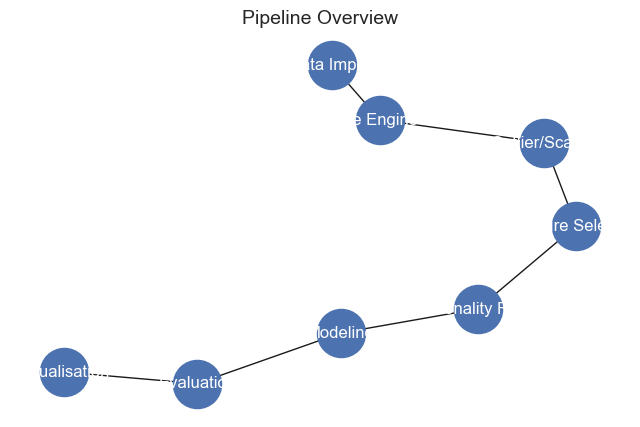

In [ ]:

import networkx as nx
G = nx.DiGraph()
G.add_edges_from([('Data Import','Feature Engineering'),('Feature Engineering','Outlier/Scaling'),('Outlier/Scaling','Feature Selection'),('Feature Selection','Dimensionality Reduction'),('Dimensionality Reduction','Modeling'),('Modeling','Evaluation'),('Evaluation','Visualisation')])
pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(8,5))
nx.draw_networkx_nodes(G,pos,node_size=1200,node_color='#4C72B0')
nx.draw_networkx_edges(G,pos,arrowstyle='->',arrowsize=15)
nx.draw_networkx_labels(G,pos,font_color='white')
plt.axis('off')
plt.title('Pipeline Overview')
plt.savefig(EXP_DIR / 'pipeline_overview.png')
plt.show()


## Feature frequency

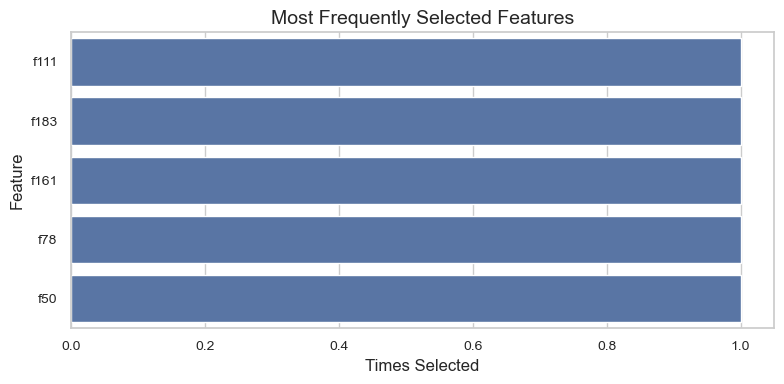

In [ ]:

selected = getattr(pipe.named_steps.get('select'),'selected_features_',[])
count_df = pd.DataFrame({'feature':selected})
feature_counts = count_df['feature'].value_counts()
plt.figure(figsize=(8,4))
sns.barplot(y=feature_counts.index, x=feature_counts.values, color='#4C72B0')
plt.xlabel('Times Selected')
plt.ylabel('Feature')
plt.title('Most Frequently Selected Features')
plt.tight_layout()
plt.savefig(EXP_DIR / 'feature_frequency.png')
plt.show()


## Distance metric comparison

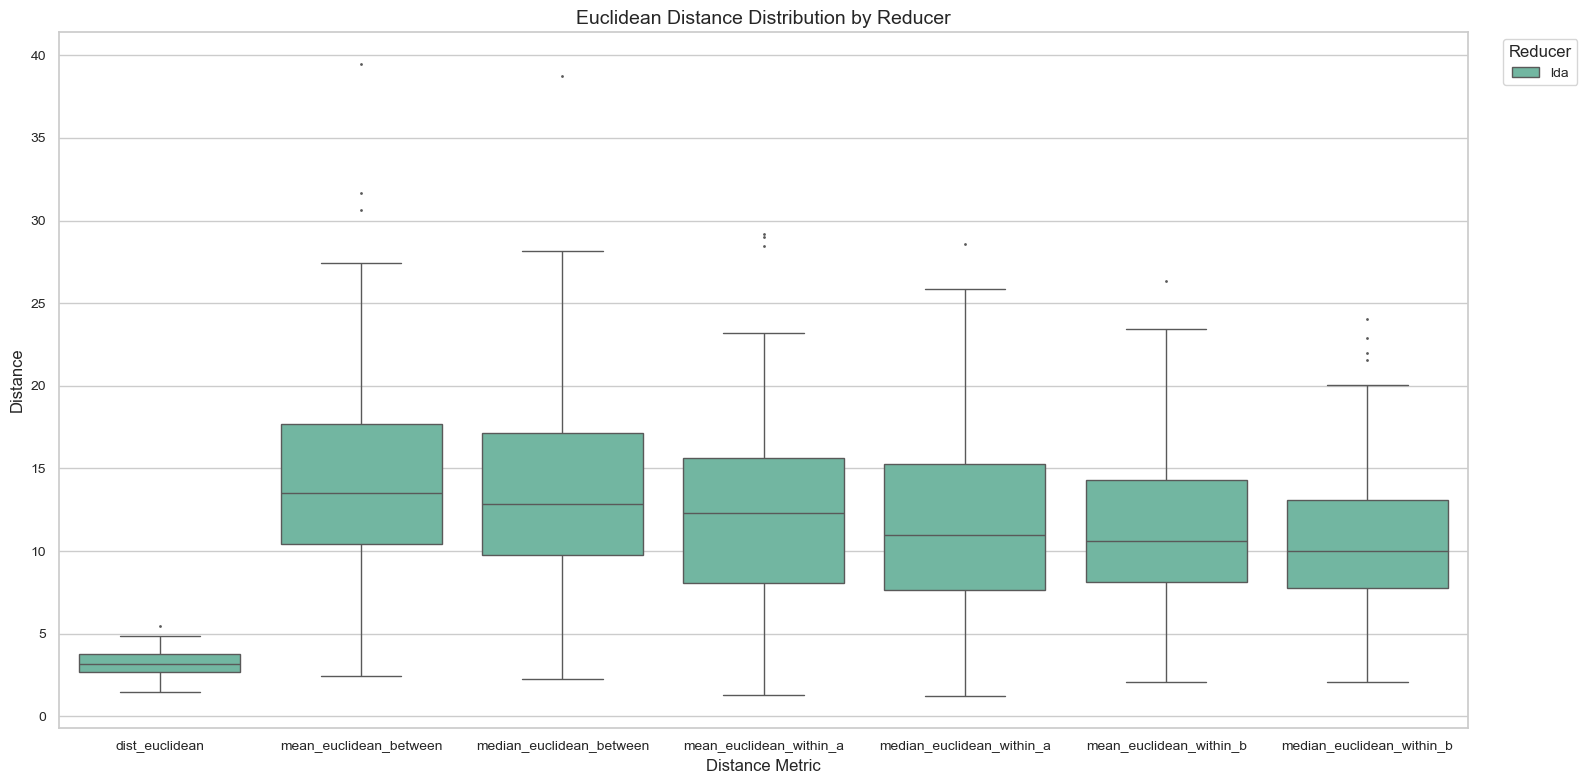

In [15]:
import math
import matplotlib.pyplot as plt
melted = res_base.melt(id_vars=['reducer'], value_vars=[c for c in res_base.columns if 'euclidean' in c or 'cosine' in c or 'manhattan' in c], var_name='metric', value_name='distance')
# 1. Alle unterschiedlichen Metrik-Namen
import matplotlib.pyplot as plt
import seaborn as sns

# Filter nur die Euclidean-Distanzen
df_euclid = melted[melted['metric'].str.contains('euclidean')]

plt.figure(figsize=(16, 8))
sns.boxplot(
    data=df_euclid,
    x='metric',    # bleibt "euclidean" für alle Einträge
    y='distance',
    hue='reducer',
    palette='Set2',
    fliersize=1
)

plt.xlabel('Distance Metric')
plt.ylabel('Distance')
plt.title('Euclidean Distance Distribution by Reducer')
plt.legend(title='Reducer', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(EXP_DIR / 'euclidean_distance_grouped.png')
plt.show()


## Embeddings 2D

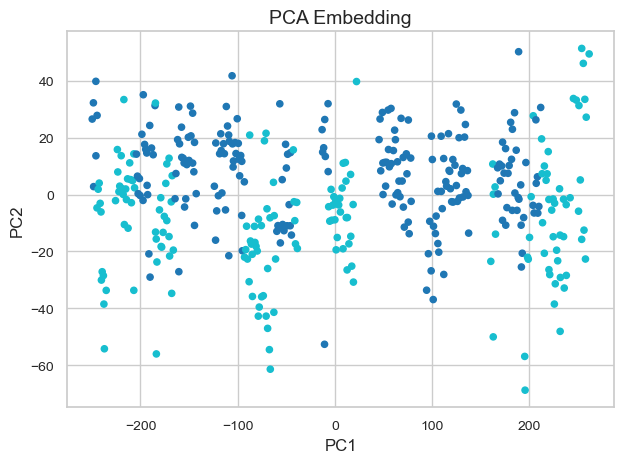

In [16]:

from sklearn.decomposition import PCA
X_emb = PCA(n_components=2).fit_transform(X_train)
plt.scatter(X_emb[:,0], X_emb[:,1], c=y_train, cmap='tab10', s=20)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Embedding')
plt.tight_layout()
plt.savefig(EXP_DIR / 'pca_embedding.png')
plt.show()


## Cumulative training times

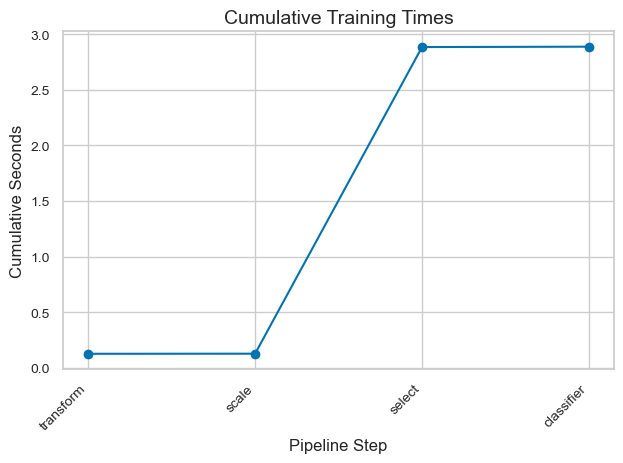

In [17]:

from time import perf_counter
steps = get_pipeline_steps(fs_method='forward', fs_k=10, scaler_method='standard')
steps.append(('classifier', MODELS['logreg_l2']))
pipe_tmp = Pipeline(steps)
X_tmp = X_train.copy()
timings = []
for name, step in pipe_tmp.steps[:-1]:
    t0 = perf_counter();
    X_tmp = step.fit_transform(X_tmp, y_train) if hasattr(step,'fit_transform') else step.fit(X_tmp, y_train).transform(X_tmp);
    timings.append({'step':name,'seconds':perf_counter()-t0})
t0=perf_counter();
pipe_tmp.steps[-1][1].fit(X_tmp,y_train);
timings.append({'step':'classifier','seconds':perf_counter()-t0})
timing_df = pd.DataFrame(timings)
timing_df['cumulative']=timing_df['seconds'].cumsum()
plt.plot(timing_df['step'], timing_df['cumulative'], marker='o')
plt.ylabel('Cumulative Seconds')
plt.xlabel('Pipeline Step')
plt.xticks(rotation=45, ha='right')
plt.title('Cumulative Training Times')
plt.tight_layout()
plt.savefig(EXP_DIR / 'cumulative_training_times.png')
plt.show()


## Hyperparameter heatmap

c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


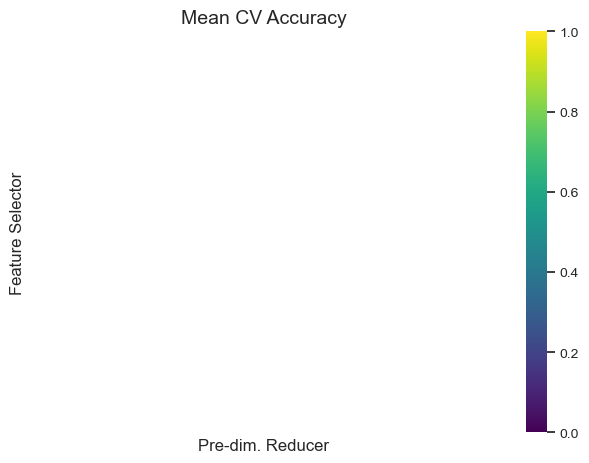

In [18]:

param_results = []
for fs in ['forward','variance']:
    steps = get_pipeline_steps(fs_method=fs, fs_k=5, scaler_method='standard')
    steps.append(('classifier', MODELS['logreg_l2']))
    pipe = Pipeline(steps)
    score = cross_val_score(pipe, X_train, y_train, cv=folds, scoring='balanced_accuracy').mean()
    param_results.append({'fs_method':fs,'reduce_pre_method':None,'cv_balanced_accuracy':score})
hyper_df = pd.DataFrame(param_results)
pivot = hyper_df.pivot_table(index='fs_method', columns='reduce_pre_method', values='cv_balanced_accuracy')
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis', vmin=0, vmax=1)
plt.xlabel('Pre-dim. Reducer')
plt.ylabel('Feature Selector')
plt.title('Mean CV Accuracy')
plt.tight_layout()
plt.savefig(EXP_DIR / 'hyperparameter_heatmap.png')
plt.show()


## Prediction quality heatmaps

In [19]:

from FIT_python.pipeline_sex.sex_predict_and_visualisation import plot_quality_heatmaps
sex_results_full = test_df.copy(); sex_results_full['pred_best_sex']=preds; sex_results_full['pred_best_proba_f']=pipe.predict_proba(X_test)[:,0]; sex_results_full['pred_best_proba_m']=pipe.predict_proba(X_test)[:,1];
plot_quality_heatmaps(sex_results_full, pred_col='pred_best_sex', proba_cols=['pred_best_proba_f','pred_best_proba_m'])


AttributeError: 'NoneType' object has no attribute 'transform'

## Split overview


[DEBUG] compute_summary called for aj_someringii/inference, df shape = (0, 141)
[DEBUG] df is empty, returning empty summary

[DEBUG] compute_summary called for aj_someringii/test, df shape = (70, 141)
[DEBUG] ds_label = aj_someringii Test
[DEBUG] species column raw: species exists? True, Species exists? False
[DEBUG] using 'species' column
[DEBUG] species_vals = ['a_j_soemmeringii']
[DEBUG] species_code = a j soemmeringii
[DEBUG] sex value counts:
sex
F    42
M    28
Name: count, dtype: int64
[DEBUG] sex = F, subset shape = (42, 141)
[DEBUG]  n_fp=42, n_ind=3, n_tr=6
[DEBUG]   fp_per_ind summary: mean=14.0, sd=0.0
[DEBUG]   tr_per_ind summary: mean=2.0, sd=0.0
[DEBUG] sex = M, subset shape = (28, 141)
[DEBUG]  n_fp=28, n_ind=2, n_tr=4
[DEBUG]   fp_per_ind summary: mean=14.0, sd=0.0
[DEBUG]   tr_per_ind summary: mean=2.0, sd=0.0
[DEBUG] sex = Unknown, subset shape = (0, 141)
[DEBUG]  n_fp=0, n_ind=0, n_tr=0
[DEBUG]   no individuals, setting means and sds to 0
[DEBUG] Returning summary

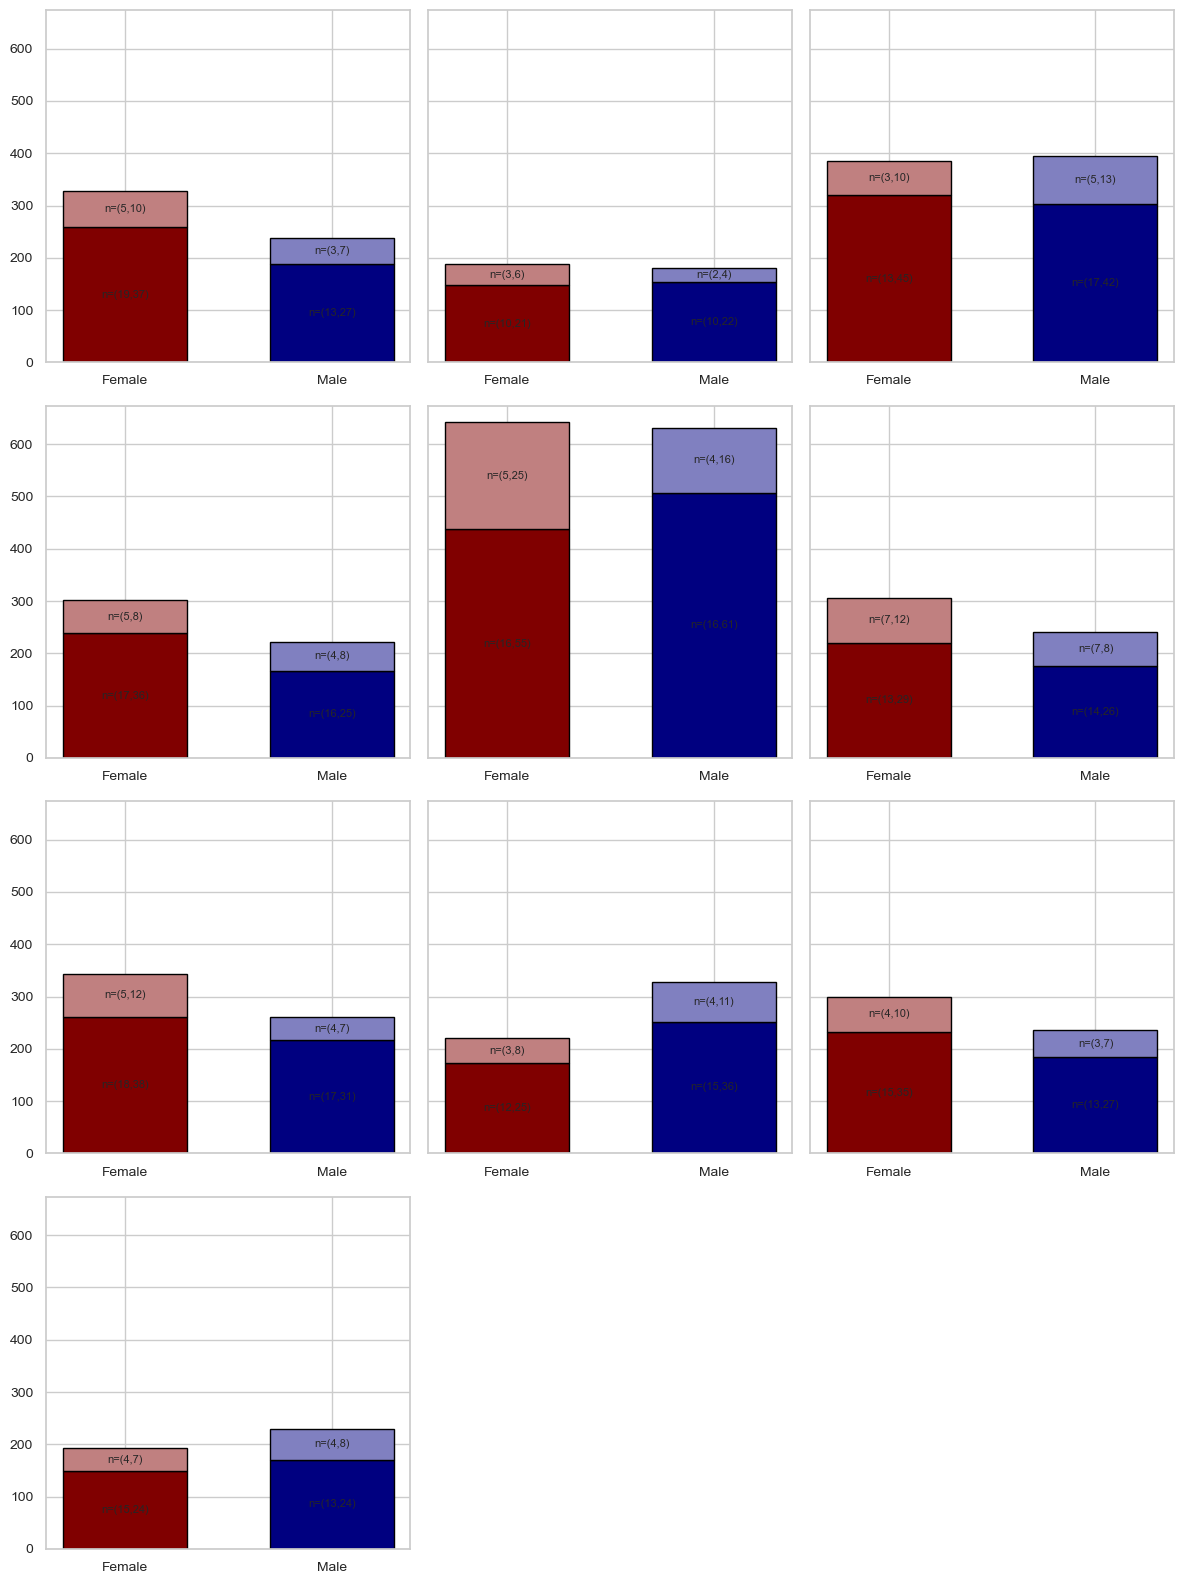

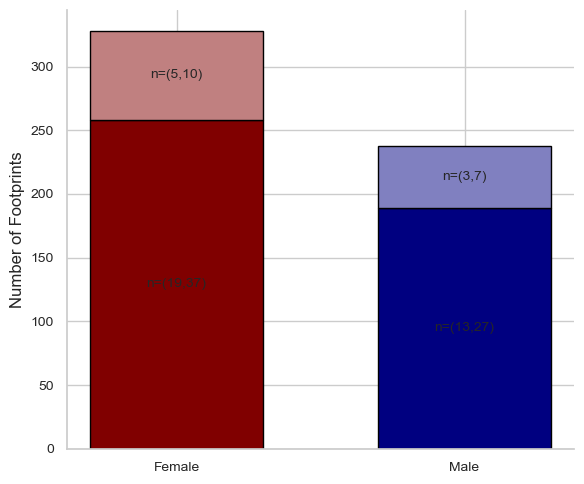

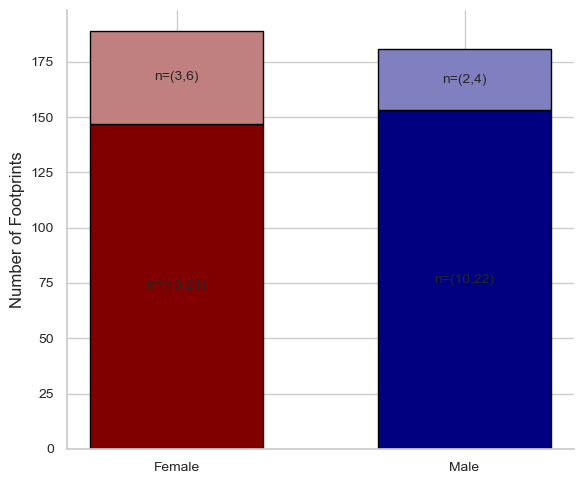

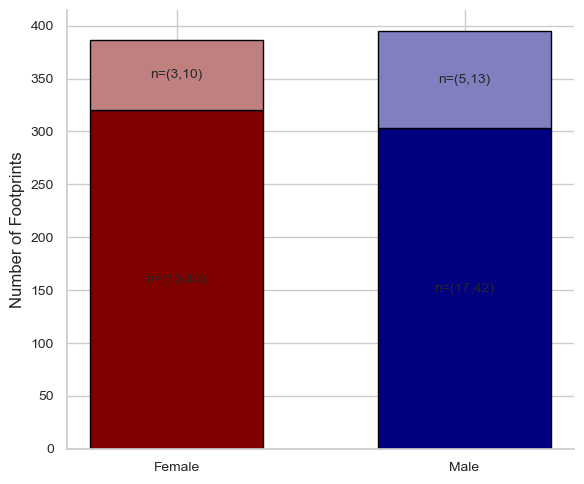

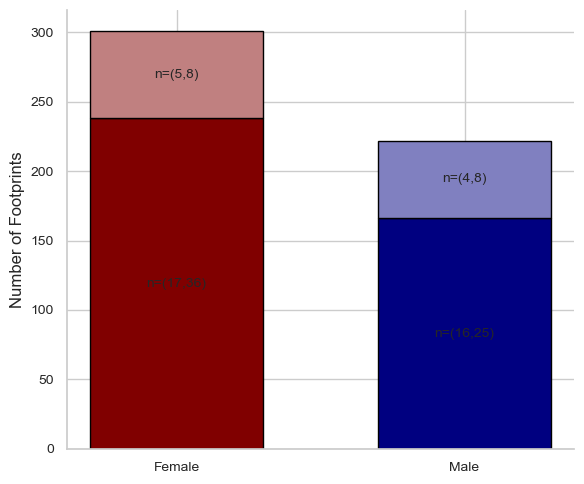

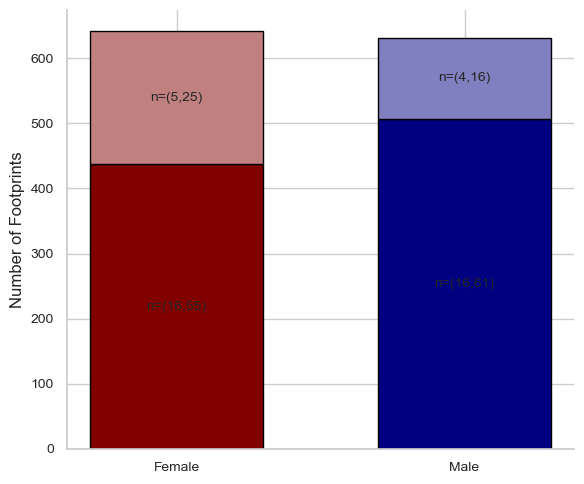

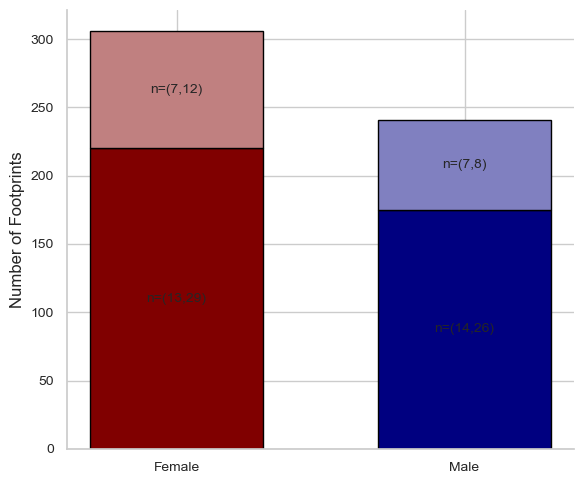

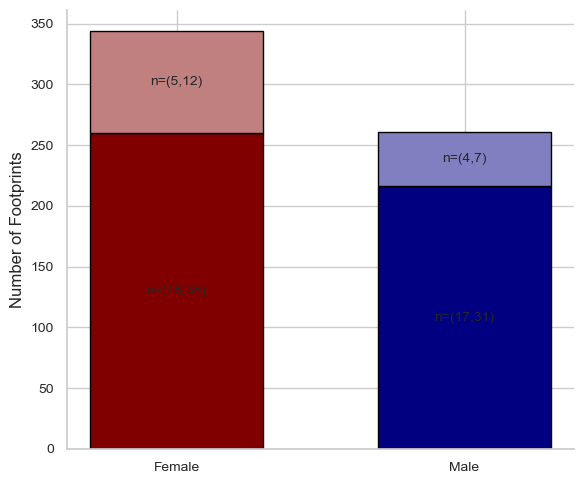

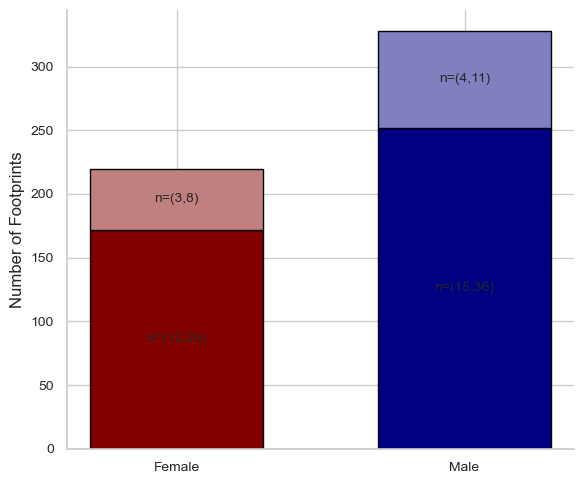

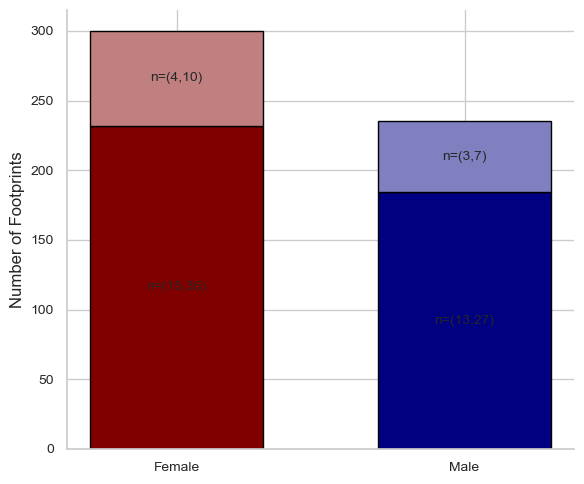

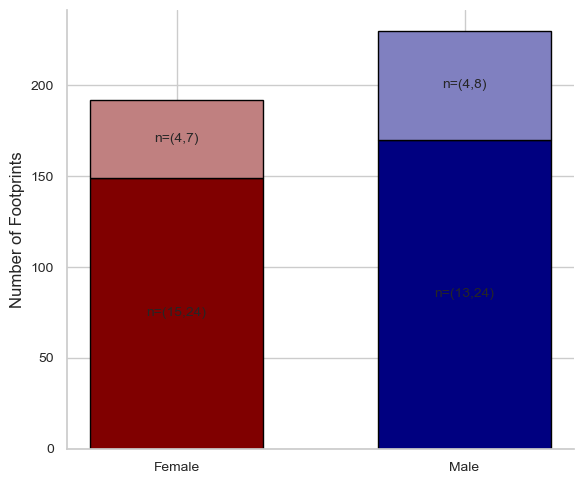

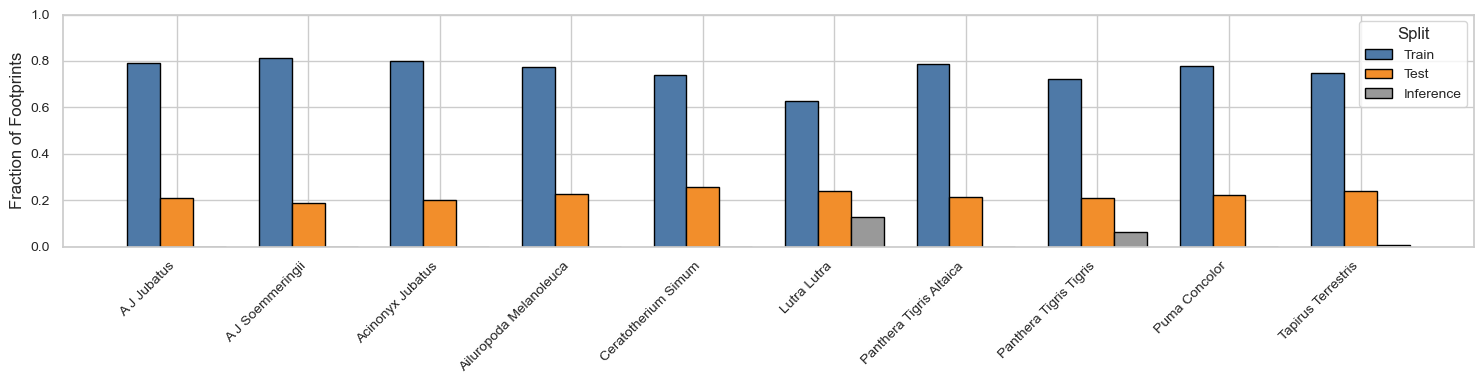

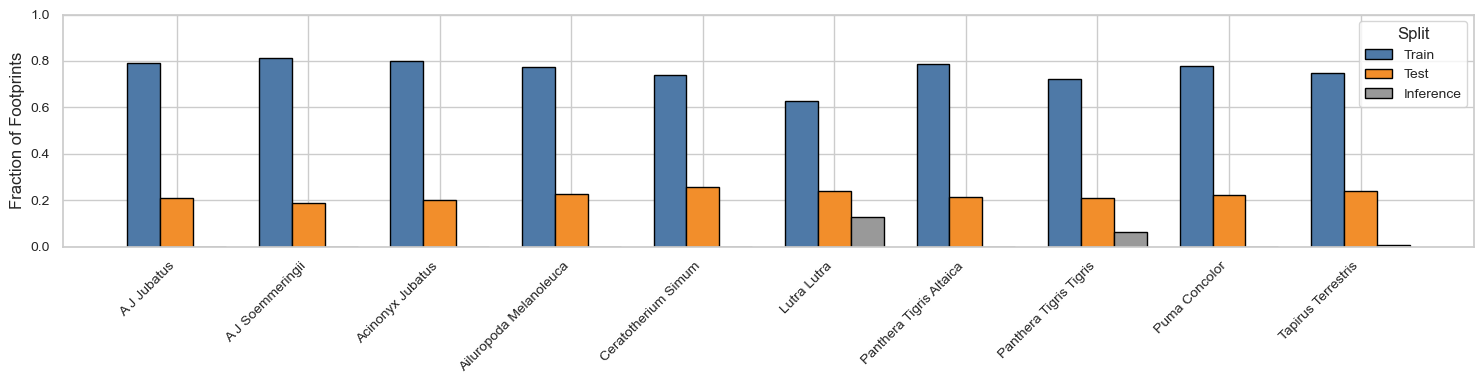

In [20]:

from FIT_python.data_split_and_summary.summary_data_wrapper import SummaryWrapper
summary_csv = EXP_DIR / 'split_summary.csv'
SummaryWrapper().summarize_all(splits_dir=EXP_DIR / 'splits', output_table=summary_csv, fig_dir=EXP_DIR/ 'summary_figs')
df_summary = pd.read_csv(summary_csv)
from FIT_python.data_split_and_summary.summary_data_utils import plot_split_proportions
plot_split_proportions(df_summary, EXP_DIR / 'summary_figs')


## Model performance over iterations

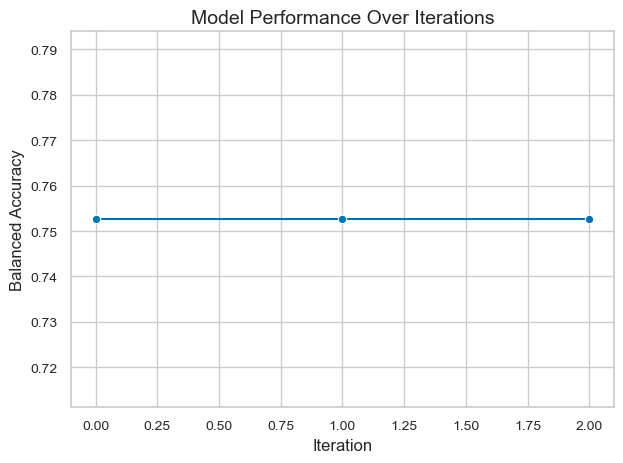

In [21]:

iterations = []
for i in range(3):
    score = cross_val_score(pipe, X_train, y_train, cv=folds, scoring='balanced_accuracy').mean()
    iterations.append({'iteration':i,'balanced_accuracy':score})
iteration_metrics = pd.DataFrame(iterations)
sns.lineplot(data=iteration_metrics, x='iteration', y='balanced_accuracy', marker='o')
plt.xlabel('Iteration')
plt.ylabel('Balanced Accuracy')
plt.title('Model Performance Over Iterations')
plt.tight_layout()
plt.savefig(EXP_DIR / 'model_performance.png')
plt.show()


## Interactive gallery

In [22]:

from ipywidgets import interact, Dropdown
from IPython.display import Image, display
fig_paths = list((EXP_DIR/'summary_figs').glob('*.png'))
def show_image(name):
    display(Image(filename=name))
dropdown = Dropdown(options=[str(p) for p in fig_paths], description='Figure:')
interact(lambda name: show_image(name), name=dropdown)


interactive(children=(Dropdown(description='Figure:', options=('experiments\\baseline_analysis\\summary_figs\\…

<function __main__.<lambda>(name)>

## Built-in: Confusion matrix

In [27]:

from FIT_python.pipeline_sex.sex_predict_and_visualisation import plot_confusion
sex_results_full = test_df.copy(); sex_results_full['pred_logreg_l2_sex']=preds
plot_confusion(sex_results_full)
plt.savefig(EXP_DIR / 'confusion_matrix.png')


KeyError: '__split__'

## Built-in: Inference split prediction

In [24]:

from FIT_python.pipeline_sex.sex_predict_and_visualisation import plot_inference
plot_inference(sex_results_full)
plt.savefig(EXP_DIR / 'inference_prediction.png')


KeyError: '__split__'

## Built-in: Individual probabilities

In [25]:

from FIT_python.pipeline_sex.sex_predict_and_visualisation import plot_individual_probabilities
plot_individual_probabilities(sex_results_full, EXP_DIR)


ValueError: DataFrame contains no probability columns ending with '_proba_m'.

## Built-in: Pipeline timings

In [26]:

from FIT_python.pipeline_sex.pipeline_wrapper_sex import plot_pipeline_timings
plot_pipeline_timings(timing_df, EXP_DIR)


[CAPTION] Average seconds per preprocessing step
[CAPTION] Average seconds per preprocessing step
